In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('C:\\Users\\KAVITA\\Downloads\\netflix_titles.csv')

In [4]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 2. Data Cleaning:

#### Check for missing values and handle them appropriately.
#### Remove duplicate entries if any.
#### Correct any inconsistencies or errors in the data

In [5]:
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
data['date_added'] = pd.to_datetime(data['date_added'], format="mixed")

In [8]:
data['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [9]:
numercial_cols = data.select_dtypes(include="number").columns.tolist()
numercial_cols

['release_year']

In [10]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'rating',
 'duration',
 'listed_in',
 'description']

In [11]:
data['date_added'] = data['date_added'].fillna(data['date_added'].mode()[0])

In [12]:
for col in categorical_cols:
    # print(col)
    print(data[col].isna().sum())
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(value=data[col].mode()[0])

print("Null values are filled successfully!")
print(data.isna().sum())

0
0
0
2634
825
831
4
3
0
0
Null values are filled successfully!
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [13]:
data.duplicated().sum()

np.int64(0)

there is no duplicate record in the system, so we can move ahead!

## Exploratory Data Analysis:

**Compute basic descriptive statistics such as mean, median, mode, range, and standard deviation for relevant variables**

In [14]:
data.describe()

,date_added,release_year
count,8807,8807.000000
mean,2019-05-17 12:13:09.735437824,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-04 00:00:00,2017.000000
75%,2020-08-18 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [15]:
data['release_year'].mode()[0]

np.int64(2018)

In [16]:
print(data['release_year'].min())
print(data['release_year'].max())

1925
2021


In [17]:
data['release_year'].std()

8.819312130834057

1. Mean -> 8807.0
2. Median -> 2017.00
3. Mode -> 2018
4. Range -> [1925, 2021]
5. standard deviation -> 8.819312130834057

In [18]:
data.describe(include="object")

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4528,7692,748,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2653,844,3649,3211,1796,362,4


##### Create visualizations to represent the distribution of content over different genres

In [19]:
data.type.unique()

array(['Movie', 'TV Show'], dtype=object)

In [20]:
data.listed_in.nunique()

514

In [21]:
result = data.groupby('listed_in').size().reset_index().rename(columns={0:"counts"})
result = result.sort_values(by="counts", ascending=False)
result = result.head(7)

In [22]:
result

,listed_in,counts
326,"Dramas, International Movies",362
274,Documentaries,359
470,Stand-Up Comedy,334
200,"Comedies, Dramas, International Movies",274
319,"Dramas, Independent Movies, International Movies",252
422,Kids' TV,220
121,Children & Family Movies,215


In [23]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Frequency')

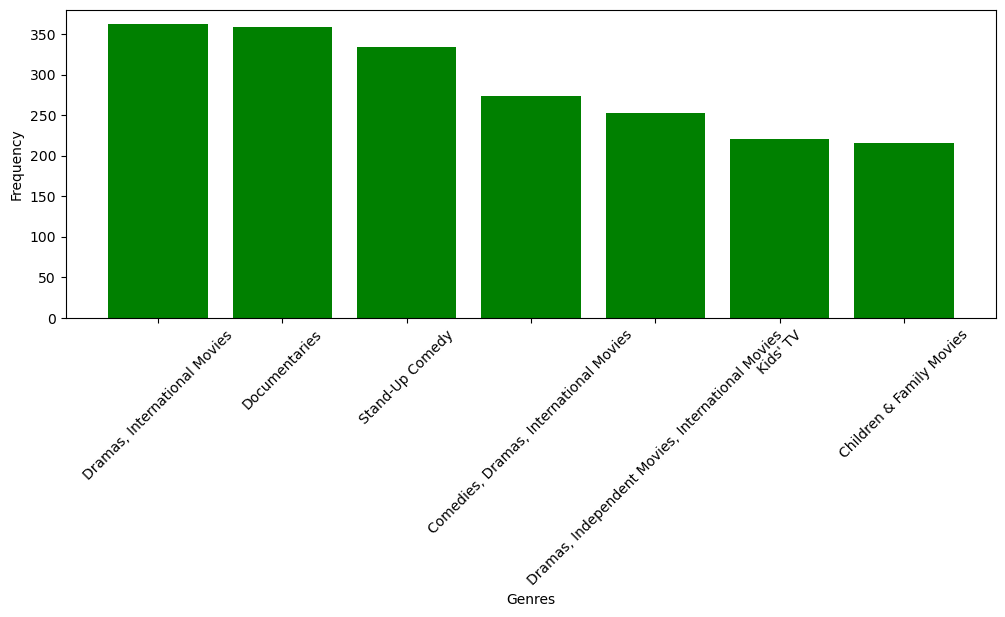

In [27]:
plt.figure(figsize=(12, 4))
plt.bar(result['listed_in'], result['counts'],color = 'green')
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Frequency")


#### insights:

1. Dramas, International Movies, and Documentaries, and Stand-up Comedy Movies are most supported by Netflix.

##### 2. Visualize the distribution of content across release years

In [28]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

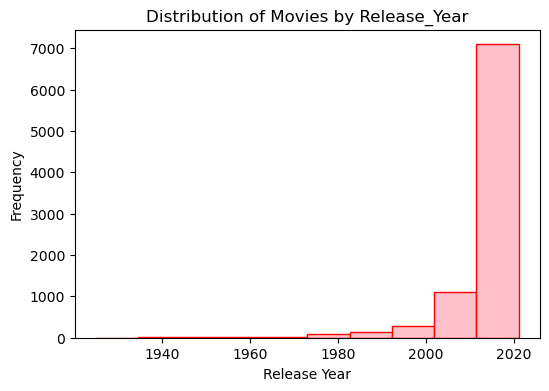

In [29]:
plt.figure(figsize=(6, 4))
plt.hist(data['release_year'], color="pink", edgecolor="red")
plt.title("Distribution of Movies by Release_Year")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [30]:
from scipy.stats import skew

skew(data['release_year'])

np.float64(-3.4459779968241837)

##### insights:

since 2010 to 2020, netflix relased highest number of movies, of above 7000.
while lowest number of films relased before 1980 , which measn, due to low accessibilty and affordability of internet over the countries.

##### 3. If there's a temporal component, perform time series analysis to identify trends and patterns over time

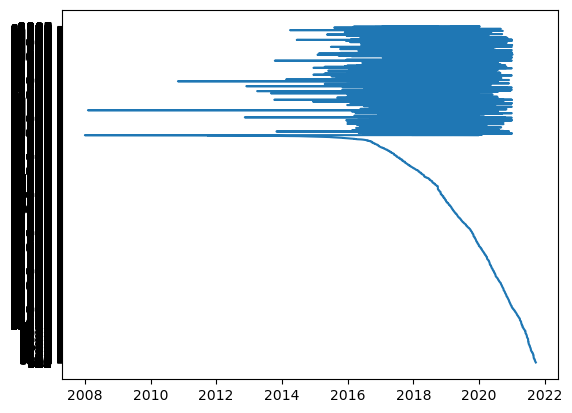

In [31]:
plt.plot(data['date_added'], data['show_id'])

In [32]:
result = data.groupby(['date_added']).size().reset_index().rename(columns={0:'counts'})
result = result.sort_values(by='date_added', ascending=True)
result

,date_added,counts
0,2008-01-01,1
1,2008-02-04,1
2,2009-05-05,1
3,2009-11-18,1
4,2010-11-01,1
...,...,...
1709,2021-09-21,5
1710,2021-09-22,9
1711,2021-09-23,2
1712,2021-09-24,10


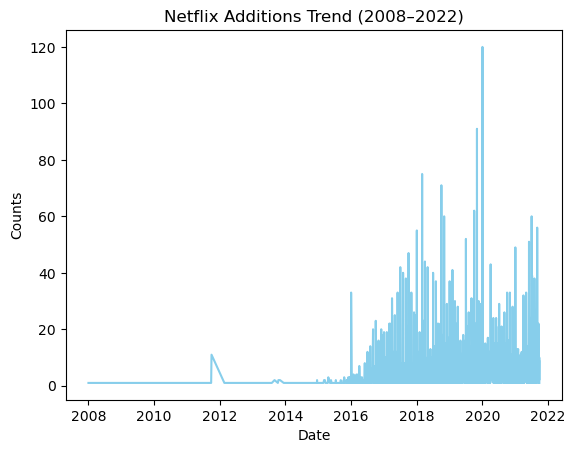

In [69]:
plt.plot(result['date_added'], result['counts'],color= 'skyblue')
plt.title("Netflix Additions Trend (2008–2022)")
plt.xlabel('Date')
plt.ylabel('Counts')
plt.show()

***The chart shows a sharp rise in counts starting around 2016, peaking in 2020, and then stabilizing at relatively high levels through 2022—indicating strong growth followed by sustained demand.***

In [34]:
month_year = data['date_added'].dt.to_period('M')
# month_year
result_2 = data.groupby(month_year).agg(counts=("show_id", "count")).reset_index()
# result_2
result_2 = result_2.sort_values(by="date_added", ascending=True)
result_2

,date_added,counts
0,2008-01,1
1,2008-02,1
2,2009-05,1
3,2009-11,1
4,2010-11,1
...,...,...
103,2021-05,132
104,2021-06,207
105,2021-07,257
106,2021-08,178


<Axes: xlabel='date_added'>

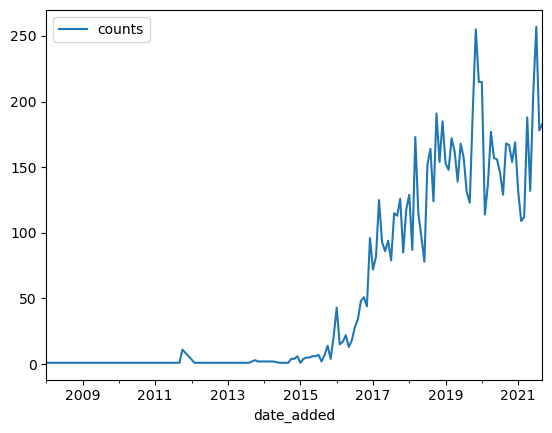

In [67]:
result_2.plot(kind="line", x='date_added', y='counts')

***chart highlights a sharp growth in counts starting around 2016, with peaks and fluctuations through 2020–2021, showing a period of heightened activity or demand.***

##### 6. Explore the length of movies or episodes and identify any trends

In [36]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [37]:
data.duration.nunique()

220

In [39]:
import seaborn as sns

In [56]:
# Count how often each duration appears
duration_counts = data['duration'].value_counts().reset_index()
duration_counts.columns = ['duration', 'count']

# Show top 10 durations
print(duration_counts.head(10))

    duration  count
0   1 Season   1796
1  2 Seasons    425
2  3 Seasons    199
3     90 min    152
4     97 min    146
5     94 min    146
6     93 min    146
7     91 min    144
8     95 min    137
9     96 min    130


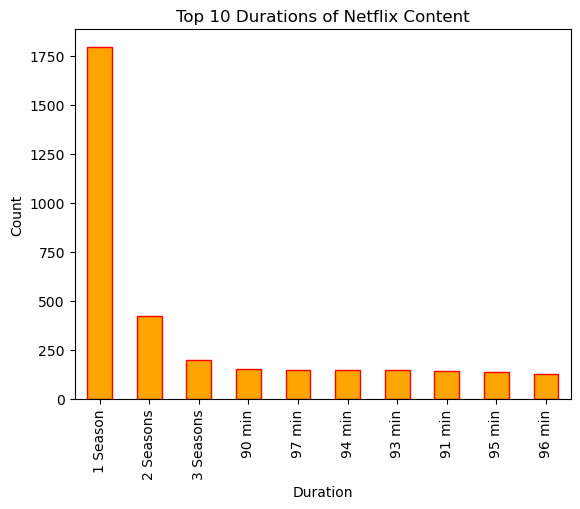

In [64]:
# Plot top 10 durations
duration_counts.head(10).plot(kind='bar', x='duration', y='count', color = 'orange',edgecolor="red", legend=False)
plt.title("Top 10 Durations of Netflix Content")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

***Shorter formats dominate—single-season shows and ~90–97 minute movies are the most common. This suggests Netflix prioritizes easily consumable content, aligning with binge-watching habits and maximizing viewer engagement. For business, it highlights the value of producing concise, high-turnover content that keeps audiences hooked without long commitments.***

In [45]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

***7.top-rated movies or TV shows based on user ratings***

In [46]:
top_rated = data.sort_values(by = 'rating',ascending = False).head(10)
print(top_rated[['title','type','rating']])

                                                  title     type    rating
8790                      You Don't Mess with the Zohan    Movie        UR
7058                                      Immoral Tales    Movie        UR
7988                                           Sex Doll    Movie        UR
7513                          Motu Patlu: King of Kings    Movie  TV-Y7-FV
7317                Little Singham aur Kaal ka Mahajaal    Movie  TV-Y7-FV
6581                                       Dear Dracula    Movie  TV-Y7-FV
7292                                       Leo the Lion    Movie  TV-Y7-FV
7646                      Oh No! It's an Alien Invasion  TV Show  TV-Y7-FV
7290  LEGO Ninjago: Masters of Spinjitzu: Day of the...    Movie  TV-Y7-FV
7499                  Monster High: New Ghoul at School    Movie     TV-Y7


# 8. Genre Trends


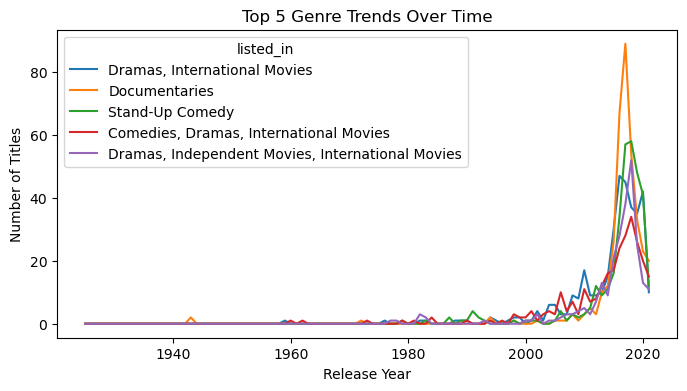

In [47]:
genre_trends = data.groupby(['release_year','listed_in']).size().unstack(fill_value = 0)
top_genre = genre_trends.sum().nlargest(5).index
genre_trends[top_genre].plot(kind= 'line',figsize=(8,4))
plt.title('Top 5 Genre Trends Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

***The surge in dramas, documentaries, and international content after 2000—peaking around 2018–2020—shows Netflix’s strategic focus on globally appealing, story-driven formats. For business, this highlights the importance of investing in diverse, culturally resonant genres to capture international markets and sustain growth.***

# 9.Geographical Analysis

In [48]:
country_counts= data['country'].value_counts().head(10)
print(country_counts)

country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


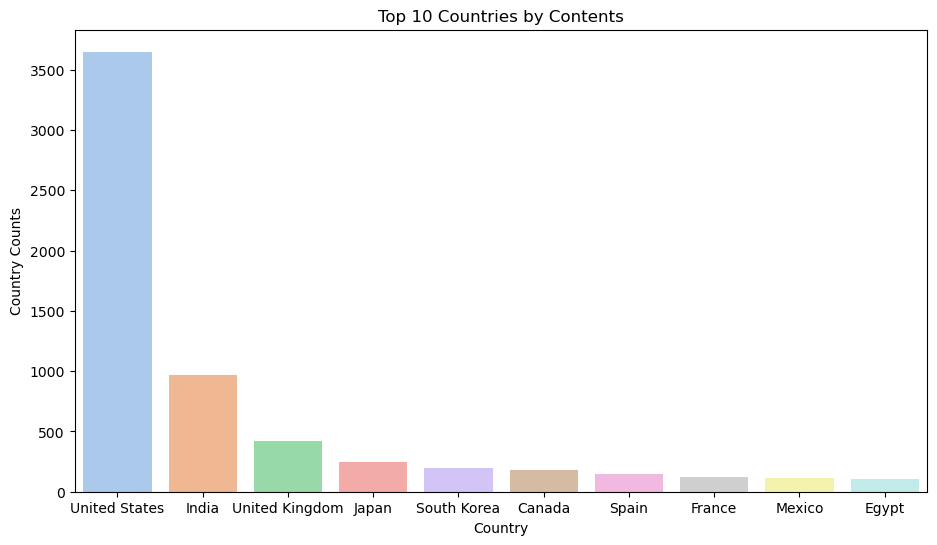

In [52]:
plt.figure(figsize = (11,6))
sns.barplot(x=country_counts.index,y=country_counts.values, hue = country_counts.index,palette="pastel",legend = False)
plt.title('Top 10 Countries by Contents')
plt.xlabel('Country')
plt.ylabel('Country Counts')
plt.show()

***Time Trends (2008–2022): Counts surged after 2016, peaked around 2020, and then stabilized at high levels.***

***Durations: Netflix favors short formats—single-season shows and ~90–97 minute movies dominate.***

***Genre Trends: Dramas, documentaries, and international content grew sharply post-2000, peaking in 2018–2020.***

***Top Countries: The U.S. leads in content volume, but India, UK, Japan, and South Korea show strong growth, reflecting Netflix’s global expansion strategy.***

# Correlation Analysis

In [53]:
data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)
avg_duration_by_rating = data.groupby('rating')['duration_num'].mean().dropna()
print(avg_duration_by_rating)

rating
66 min        1.000000
74 min        1.000000
84 min        1.000000
G            90.268293
NC-17       125.000000
NR           88.862500
PG           98.282230
PG-13       108.330612
R           106.455569
TV-14        73.481481
TV-G         46.418182
TV-MA        62.226409
TV-PG        59.975666
TV-Y         21.592834
TV-Y7        28.766467
TV-Y7-FV     57.333333
UR          106.333333
Name: duration_num, dtype: float64


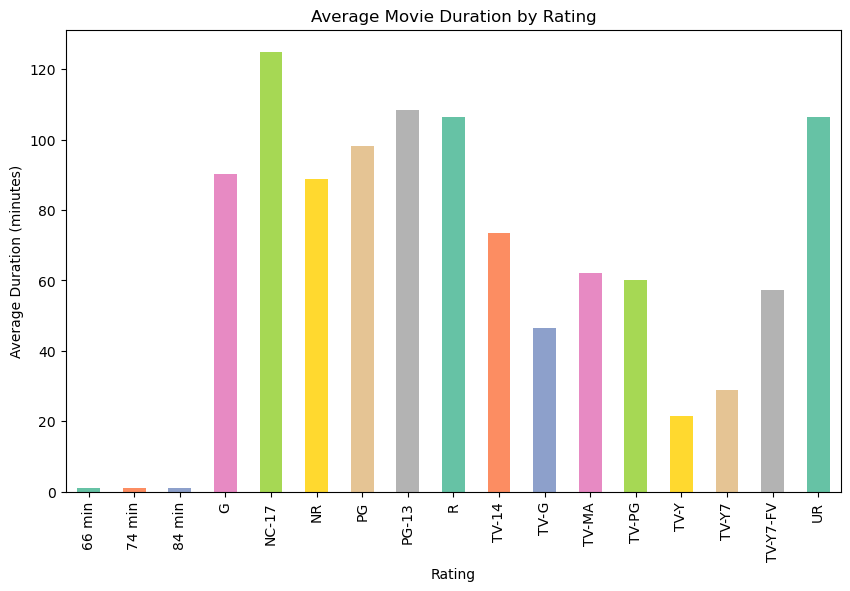

In [54]:
plt.figure(figsize=(10,6))
colors = sns.color_palette("Set2", len(avg_duration_by_rating))
avg_duration_by_rating.plot(kind='bar', color=colors)
plt.title("Average Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Duration (minutes)")
plt.show()


***Movies rated for general or family audiences (like TV-Y, TV-PG) tend to have shorter average durations, while adult-oriented ratings (like R or TV-MA) show longer runtimes. This reflects Netflix’s strategy of tailoring content length to audience expectations—shorter for casual/family viewing, longer for mature, story-driven experiences.***

## Conclusion

***this project, the Netflix dataset was analyzed to understand the distribution and trends of movies and TV shows on the platform. After cleaning and exploring the data, several patterns were identified related to release years, content types, and genres. The analysis shows that movies make up a large portion of Netflix content and most titles were released in recent years. This project demonstrates how data analysis and visualization can help uncover meaningful insights from real-world datasets.***
